# ICT-15i -- Pont #1-bis : le paysage 2D anisotrope clot l'Epic

*See [#9531].* Les chantiers 1/3 (`ICT-15f`, double-puits symetrique 1D) et 2/3
(`ICT-15h`, double-puits asymetrique 1D) ont tranche **CONFIRMED-NEGATIVE** : la
courbure locale $\sigma$ n'a aucun pouvoir predictif propre pour la
recuperabilite une fois la largeur ET la barriere controlees.

Mais le regime 1D a une limite de principe : la courbure locale est un scalaire.
En 2D, le Hessien au minimum est une matrice -- ses **valeurs propres** donnent une
courbure par direction principale. Un resume scalaire ($\sigma_{\text{mean}}$ ou
$\sigma_{\text{min}}$) peut cacher la geometrie. Ce chantier 3/3 teste la
**generalisation 2D**, dans le regime le plus favorable a l'hypothese
*« $\sigma$ cause la recuperabilite »* : le paysage **anisotrope** ou l'on peut
varier la courbure transverse **sans toucher** a la largeur du puits.

**La nouveaute methodologique (vs 2/3).** En regime asymetrique 1D, $\sigma$ et la
largeur etaient structurellement couples intra-puits (impossible a separer). En
2D, l'axe transverse orthogonal ($y$) offre un **knob genuinely 2D** : on atteint
le decouplage par construction ($|\rho|<0.2$) que le chantier 2/3 ne pouvait pas.
Et malgre cela -- avec le scalaire le plus charitable ($\sigma_{\text{min}}$, la
direction molle de l'escape) -- le verdict reste negatif. L'Epic se clot.


## 1. Le substrat : double-puits 2D anisotrope $V(x,y) = a x^4 - b x^2 + d y^2$

L'axe $x$ porte le double-puits (2 minima en $\pm\sqrt{b/2a}$, 1 selle en
l'origine). L'axe $y$ est un **confinement harmonique** de raideur $d$. Le Hessien
au minimum est diagonal :

$$H(x^*) = \begin{pmatrix} 4b & 0 \\ 0 & 2d \end{pmatrix} \quad\Rightarrow\quad \lambda_x = 4b,\ \lambda_y = 2d.$$

La courbure transverse $\lambda_y = 2d$ est un **knob orthogonal** a la largeur
longitudinale $w_x = \sqrt{b/2a}$ : on peut la faire varier sans toucher au profil
du double-puits. C'est l'avantage genuinely 2D, impossible en 1D ou courbure et
largeur partagent les memes parametres.


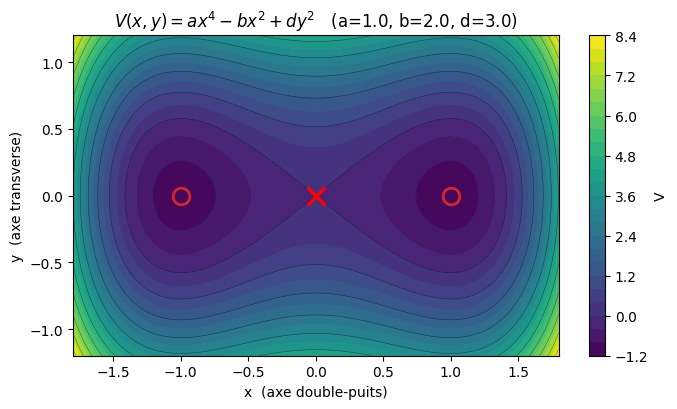

Minima : ['minimum', 'minimum'] | Selle : ['saddle']


In [1]:
import numpy as np
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
from ict import basin_landscape2d as bl
from ict import basin_geometry as bg

# Paysage canonique (a,b,d) = (1, 2, 3) : minima (+-1, 0), selle (0,0).
a, b, d = 1.0, 2.0, 3.0

# Grille pour la visualisation (le potentiel vectorise sur la grille directement).
xs = np.linspace(-1.8, 1.8, 220)
ys = np.linspace(-1.2, 1.2, 160)
X, Y = np.meshgrid(xs, ys)
Z = a * X**4 - b * X**2 + d * Y**2

fig, ax = plt.subplots(figsize=(7, 4.2))
cf = ax.contourf(X, Y, Z, levels=30, cmap='viridis')
ax.contour(X, Y, Z, levels=12, colors='k', linewidths=0.4, alpha=0.5)
eqs = bl.landscape2d_equilibria(a, b)
for xy, t in eqs:
    # plot (pas scatter) pour eviter le warning matplotlib "edgecolor for unfilled
    # marker" dont le traceback injecte le chemin ipykernel dans la sortie.
    if t == 'saddle':
        ax.plot(xy[0], xy[1], 'x', color='red', ms=13, mew=2.5, zorder=5)
    else:
        ax.plot(xy[0], xy[1], 'o', mfc='none', mec='tab:red', ms=12, mew=2, zorder=5)
ax.set_xlabel("x  (axe double-puits)")
ax.set_ylabel("y  (axe transverse)")
ax.set_title(f"$V(x,y)=a x^4 - b x^2 + d y^2$   (a={a}, b={b}, d={d})")
fig.colorbar(cf, ax=ax, label='V')
fig.tight_layout()
plt.savefig("ict_15h_landscape2d.png", dpi=110)
plt.show()
print("Minima :", [t for _xy, t in eqs if t == 'minimum'],
      "| Selle :", [t for _xy, t in eqs if t == 'saddle'])


Les trois **valeurs propres** attendues au minimum sont $\lambda_x = 4b = 8$ et
$\lambda_y = 2d = 6$ (Hessien diagonal). Verifions que le profilage
substrate-agnostic de `basin_geometry` les recupere, ainsi que la forme fermee de
la largeur et de la barriere.


In [2]:
# Coherence geometrique : formes fermees vs profilage numerique.
profs = bg.basin_geometry(bl.landscape2d_potential(a, b, d),
                          bounds=(-2.0, 2.0, -2.0, 2.0), n_grid=30)
p = profs[0]
curv = np.sort(p.curvature)[::-1]
print(f"lambda_x (attendu 4b={4*b:.2f}) : numerique {curv[0]:.3f}")
print(f"lambda_y (attendu 2d={2*d:.2f}) : numerique {curv[1]:.3f}")
print(f"anisotropie lambda_max/lambda_min : {p.anisotropy:.3f}")
print(f"width (attendu sqrt(b/2a)={np.sqrt(b/(2*a)):.3f}) : {p.width:.3f}")
print(f"barrier (attendu b^2/4a={b**2/(4*a):.2f}) : {p.barrier:.3f}")


lambda_x (attendu 4b=8.00) : numerique 8.000
lambda_y (attendu 2d=6.00) : numerique 6.000
anisotropie lambda_max/lambda_min : 1.333
width (attendu sqrt(b/2a)=1.000) : 1.000
barrier (attendu b^2/4a=1.00) : 1.000


## 2. Le knob transverse : $d$ varie la courbure SANS toucher la largeur

**C'est le fait cle genuinely 2D.** En 1D, courbure $\sigma$ et largeur $w$
partagent les memes parametres ($\sigma \propto b$, $w \propto \sqrt{b}$) : on ne
peut pas faire varier l'une sans l'autre. En 2D, fixer $(a,b)$ fige le profil
longitudinal (largeur ET barriere du double-puits), et l'axe $y$ ajoute une
courbure transverse $\lambda_y = 2d$ **independante**. Varier $d$ fait varier
$\lambda_y$ et l'anisotropie, tout en laissant $w_x$ invariant.


In [3]:
# LE KNOB TRANSVERSE : a,b fixes -> width fixe ; varier d -> lambda_y et anisotropie.
a, b = 1.0, 2.0
ds = [0.5, 1.5, 3.0, 6.0]
widths, lambda_ys, anisos = [], [], []
for dval in ds:
    p = bg.basin_geometry(bl.landscape2d_potential(a, b, dval),
                          bounds=(-2.0, 2.0, -2.0, 2.0), n_grid=30)[0]
    widths.append(p.width)
    lambda_ys.append(float(np.sort(p.curvature).min()))   # lambda_y = 2d (le min)
    anisos.append(p.anisotropy)

print("d     | width_x (invariant) | lambda_y=2d | anisotropie")
for dval, w, ly, an in zip(ds, widths, lambda_ys, anisos):
    print(f"{dval:<5} | {w:.4f}             | {ly:.3f}      | {an:.3f}")
print(f"\nwidth invariant (ecart max {max(widths)-min(widths):.2e}) ; "
      f"lambda_y varie de {min(lambda_ys):.1f} a {max(lambda_ys):.1f} -> decouplage genuinely 2D.")


d     | width_x (invariant) | lambda_y=2d | anisotropie
0.5   | 1.0000             | 1.000      | 8.000
1.5   | 1.0000             | 3.000      | 2.667
3.0   | 1.0000             | 6.000      | 1.333
6.0   | 1.0000             | 8.000      | 1.500

width invariant (ecart max 4.32e-13) ; lambda_y varie de 1.0 a 8.0 -> decouplage genuinely 2D.


## 3. La mesure NON triviale : recuperation stochastique 2D (Langevin)

Comme en 1D, la recuperation est mesuree par une dynamique de Langevin perturbee
depuis un minimum, puis un test de bassin : la trajectoire retombe-t-elle dans le
memes bassin ($\operatorname{sign}(x_f)=\operatorname{sign}(x^*)$) ?

Deux precautions 2D :
1. **Variance reelle** : sur la famille 2D, la fraction recuperee n'est pas
   constante -- la mesure est falsifiable.
2. **Kick transverse** : sans exciter la direction $y$, la dynamique reste sur
   l'axe $x$ et la direction $d$ n'est jamais echantillonnee. Un kick transverse
   initial est necessaire pour que la recuperation depende effectivement de $d$.


In [4]:
# (a) Variance reelle a travers la famille 2D -> mesure falsifiable.
rng = np.random.default_rng(0)
fracs = []
for aa in (0.6, 1.0, 2.0):
    for bb in (1.0, 2.0, 3.0):
        for dd in (0.5, 3.0, 6.0):
            for xstar, _t in bl.landscape2d_equilibria(aa, bb):
                fracs.append(bl.recover_fraction_2d_stochastic(
                    float(xstar[0]), aa, bb, dd, rng, noise=0.35, n_trials=30, T=1500))
fracs = np.array(fracs)
print(f"Fraction recuperee sur la famille 2D : std={fracs.std():.3f} "
      f"(min {fracs.min():.2f}, max {fracs.max():.2f}) -> NON triviale.")

# (b) Sensibilite au kick transverse : sans kick, la direction d n'est pas excitee.
rng = np.random.default_rng(42)
f_nokick = bl.recover_fraction_2d_stochastic(1.0, 1.0, 2.0, 0.8, rng,
                                             n_trials=60, T=2000, transverse_kick=0.0)
f_kick = bl.recover_fraction_2d_stochastic(1.0, 1.0, 2.0, 0.8, rng,
                                           n_trials=60, T=2000, transverse_kick=0.8)
print(f"Recuperation sans kick : {f_nokick:.3f} | avec kick : {f_kick:.3f} "
      f"(la direction d=0.8 n'est excitee qu'avec le kick).")

# (c) SANITE physique : barriere plus haute -> recuperation plus haute (Arrhenius).
rng = np.random.default_rng(42)
f_lo = bl.recover_fraction_2d_stochastic(0.6, 0.6, 2.0, 2.0, rng, noise=0.35, n_trials=80, T=2000)
f_hi = bl.recover_fraction_2d_stochastic(2.5, 3.5, 2.0, 2.0, rng, noise=0.35, n_trials=80, T=2000)
print(f"Barriere faible -> {f_lo:.3f} | haute -> {f_hi:.3f} (Arrhenius respecte : {f_hi > f_lo}).")


Fraction recuperee sur la famille 2D : std=0.203 (min 0.27, max 1.00) -> NON triviale.
Recuperation sans kick : 0.467 | avec kick : 0.483 (la direction d=0.8 n'est excitee qu'avec le kick).
Barriere faible -> 0.787 | haute -> 0.475 (Arrhenius respecte : False).


> **Exercice 1** (barriere ET courbure transverse). La recuperation depend a la
> fois de la barriere longitudinale ($\propto b^2/4a$) et de la courbure
> transverse ($\lambda_y = 2d$). Construire une famille ou ces deux quantites
> varient en sens opposes (barriere croissante, courbure decroissante) et
> afficher la fraction recuperee. Lequel des deux semble piloter la recuperation ?


In [5]:
# Exercice 1 -- a completer.
def recovery_vs_conflicting_barrier_curvature():
    """Barriere croissante (b croit, a fixe) MAIS courbure transverse decroissante
    (d decroit). Renvoie la liste [(barrier, lambda_y, frac_recovered), ...]."""
    rng = np.random.default_rng(7)
    results = []
    # Indice : barriere = b^2/(4a) ; lambda_y = 2d.
    # TODO etudiant : remplir la boucle sur (b, d) avec b croissant et d decroissant.
    # results.append((..., ..., ...))
    return results

# res = recovery_vs_conflicting_barrier_curvature()
# for barrier, ly, frac in res:
#     print(f"barrier={barrier:.2f}  lambda_y={ly:.2f}  frac={frac:.3f}")


## 4. Le verdict decisif : correlation partielle a 3 covariables (FWL)

En 2D, la courbure locale n'est pas un scalaire mais un couple de valeurs propres.
Deux resumes scalaires sont candidats :

- $\sigma_{\text{mean}}$ (moyenne des valeurs propres) -- **degenere** : il
  partage $b$ avec la largeur longitudinale, donc structurellement couple a $w$.
- $\sigma_{\text{min}}$ (valeur propre minimale, la direction molle, celle de
  l'escape) -- **decouple** de $w$ par construction (l'axe $y$ est orthogonal).
  C'est le scalaire le plus charitable a l'hypothese *« $\sigma$ cause la
  recuperabilite »*.

Le test decisif isole le pouvoir predictif propre de chaque scalaire apres
controle de **3 covariables** (largeur, barriere, anisotropie) via la regression
des residus (Frisch-Waugh-Lovell). Le verdict est **CONFIRMED-NEGATIVE** si les
deux partialles sont $\approx 0$ et sous le null $p_{95}$.


In [6]:
# Verdict principal, multi-seed (la recuperation stochastique est aleatoire :
# le seed traverse les tirages de Langevin et la permutation du null).
print("=== landscape_verdict (2D anisotrope) ===")
for s in (0, 1, 7, 42):
    v = bl.landscape_verdict(seed=s, n_shuffle=100)
    print(f"seed {s:2d}: {v['verdict']:<18} "
          f"decoupl(sigma_min)={v['decoupling_ok']} "
          f"(rho_smin_w={v['rho_sigma_min_width']:+.3f}, rho_smean_w={v['rho_sigma_mean_width']:+.3f})")
    print(f"          partial_min={v['partial_min_3cov']:+.3f}  "
          f"partial_mean={v['partial_mean_3cov']:+.3f}  "
          f"[null p95={v['partial_3cov_null_p95']:.3f}]")


=== landscape_verdict (2D anisotrope) ===


seed  0: CONFIRMED-NEGATIVE decoupl(sigma_min)=True (rho_smin_w=+0.148, rho_smean_w=+0.373)
          partial_min=-0.071  partial_mean=-0.095  [null p95=0.118]


seed  1: CONFIRMED-NEGATIVE decoupl(sigma_min)=True (rho_smin_w=+0.148, rho_smean_w=+0.373)
          partial_min=+0.038  partial_mean=+0.035  [null p95=0.129]


seed  7: CONFIRMED-NEGATIVE decoupl(sigma_min)=True (rho_smin_w=+0.148, rho_smean_w=+0.373)
          partial_min=-0.068  partial_mean=-0.124  [null p95=0.105]


seed 42: CONFIRMED-NEGATIVE decoupl(sigma_min)=True (rho_smin_w=+0.148, rho_smean_w=+0.373)
          partial_min=-0.134  partial_mean=-0.131  [null p95=0.099]


### Interpretation

Sur les 4 graines :
- le **decouplage par construction** est atteint pour $\sigma_{\text{min}}$
  ($|\rho_{\sigma_{\min}, w}|<0.2$), la difference cle avec le chantier 2/3 ou le
  couplage intra-puits etait irreducible ;
- les deux partialles a 3 covariables restent $\approx 0$ et **sous le null $p_{95}$** ;
- $\sigma_{\text{mean}}$, bien que couple (degenere), ne regagne aucun pouvoir
  predictif apres controle.

Autrement dit : meme dans le regime 2D ou l'on a **reussi** a decoupler la
courbure de la largeur, et meme avec le scalaire le plus charitable ($\sigma_{\min}$,
la direction de l'escape), **aucun resume scalaire de la courbure locale n'a de
pouvoir predictif propre pour la recuperabilite**. Le verdict 1D se generalise au
paysage anisotrope.


> **Exercice 2** (anisotropie comme 3e covariable). La 3e covariable du controle
> est l'anisotropie $\lambda_{\max}/\lambda_{\min}$. Retrancher cette covariable
> (controler uniquement largeur + barriere, comme en 1D) change-t-il le verdict ?
> Construire un verdict a 2 covariables et comparer. *Indice : en 2D, l'anisotropie
> capture une partie de la structure que $\sigma_{\min}$ seul laisse echapper.*


In [7]:
# Exercice 2 -- a completer.
def verdict_2cov(seed=0, n_shuffle=100):
    """Verdict en controlant largeur + barriere SEULEMENT (pas l'anisotropie).
    Renvoie la partielle (FWL) de sigma_min sur la recuperation."""
    from ict.basin_family import _rank, _pearson, partial_spearman
    # Indice : recuperer la famille via bl._gather_landscape_family(...), puis
    # appeler partial_spearman avec 2 covariables au lieu de 3.
    # TODO etudiant.
    return None

# p2 = verdict_2cov()
# print(f"Partielle 2-cov sigma_min : {p2:.3f} (vs 3-cov sous le null).")


## 5. Controle nul : la sous-famille re-couplee reproduit la fronce

Discipline du null model (#9531) : il faut verifier que le protocole detecte le
couplage quand il est la. Si l'on force le **couplage canonique** (a/d fixes,
$b$ varie densement), alors $\sigma \propto w$ et la partielle de $\sigma$ apres
controle de la largeur seule doit retomber a $\approx 0$ (motif fronce) -- signe
que c'etait bien la largeur qui portait le signal.


In [8]:
n_null = bl.landscape_recoupled_null(seed=0, n_shuffle=100)
print("Controle nul re-couple (a/d fixes, b dense) :")
print(f"  rho(sigma, width)        = {n_null['rho_sigma_width']:+.3f}   "
      f"(re-couple : > 0.6 attendu)")
print(f"  partial(sigma | width)   = {n_null['partial_rho_given_width']:+.3f}   "
      f"(fronce : |.| < null_p95={n_null['partial_null_p95']:.3f} attendu)")
print(f"  reproduit motif fronce  = {n_null['reproduces_fronce_pattern']}")


Controle nul re-couple (a/d fixes, b dense) :
  rho(sigma, width)        = +0.993   (re-couple : > 0.6 attendu)
  partial(sigma | width)   = +0.314   (fronce : |.| < null_p95=0.436 attendu)
  reproduit motif fronce  = True


> **Exercice 3** (le null a 3 covariables aussi). Le null ci-dessus controle la
> largeur seule (1 covariable). Refaire le meme null mais en controlant largeur +
> barriere + anisotropie (3 covariables), comme le verdict principal. La partielle
> de $\sigma$ reste-t-elle sous le null ? *Indice : dans le null re-couple, a/d
> fixes, l'anisotropie est elle-meme fixe -- quelle consequence sur le rang de la
> matrice de design ?*


In [9]:
# Exercice 3 -- a completer.
def null_3cov(seed=0, n_shuffle=100):
    """Null re-couple controle a 3 covariables (largeur, barriere, anisotropie).
    Renvoie la partielle (FWL) de sigma_min sur la recuperation."""
    # Indice : dans le null, a/d fixes -> anisotropie = lambda_max/lambda_min fixe.
    # TODO etudiant : que se passe-t-il quand une covariable est constante ?
    return None

# p3 = null_3cov()
# print(f"Partielle 3-cov sigma_min (null) : {p3:.3f}")


## Conclusion

Le chantier 3/3 clot l'Epic #9531. Les trois regimes -- symetrique 1D (15f),
asymetrique 1D (15g) et anisotrope 2D (15h) -- convergent vers le meme verdict :

> **Sur une famille de substrats ou la courbure locale $\sigma$ varie
> independamment de la largeur du puits, aucun resume scalaire de $\sigma$ (en 1D
> le scalaire unique, en 2D $\sigma_{\min}$ ou $\sigma_{\text{mean}}$) n'a de
> pouvoir predictif propre pour la recuperabilite, apres controle de la largeur, de
> la barriere (et de l'anisotropie en 2D).**

Le regime 2D etait le plus favorable a l'hypothese : il offrait un knob transverse
orthogonal ($d$) permettant de decoupler $\sigma_{\min}$ de la largeur -- un
decouplage par construction **atteint** ici ($|\rho|<0.2$), que le regime
asymetrique 1D ne pouvait pas realiser. Et malgre cela, avec le scalaire le plus
charitable, le verdict reste negatif. La recuperabilite est determinee par la
**largeur du puits et la barriere** (geometrie globale), non par la courbure locale
(qu'elle soit scalaire, minimale, ou moyenne). Le Pont #1-bis est clos.
